# Day 5 - Recommendation Engine

# Placement Prediction & Recommendation Platform

This notebook develops an intelligent recommendation engine that provides personalized career guidance based on student profiles and placement predictions generated by the machine learning models.

The recommendation engine analyzes academic performance, technical skills, projects, internships, career preferences, and predicted placement probability to generate actionable recommendations for improving placement outcomes.

The recommendations generated in this notebook will be integrated into the Placement Intelligence Platform to assist students in making informed career decisions.

The recommendation engine developed in this notebook will provide:

- Student Performance Recommendations
- Company Recommendations
- Job Role Recommendations
- Skill Gap Analysis
- Personalized Career Guidance
- Placement Readiness Assessment

## Objectives

The primary objectives of this notebook are:

- Load the trained machine learning model
- Predict placement probability for individual students
- Build a personalized student recommendation system
- Recommend suitable companies based on student profiles
- Recommend appropriate job roles aligned with student strengths
- Perform skill gap analysis by identifying missing technical skills
- Generate personalized career guidance reports
- Assess overall placement readiness
- Create a recommendation pipeline for deployment in the Placement Intelligence Platform
- Prepare the recommendation engine for Gradio dashboard integration

## Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import mysql.connector
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

## Connect to MySQL

In [2]:
import os

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=os.getenv("MYSQL_PASSWORD"),
    database="placement_platform"
)

cursor = conn.cursor()

print("✅ Connected Successfully!")

Connected Successfully!


# Load Saved Objects

## Load Random Forest Model

In [3]:
placement_model = joblib.load("../models/placement_model.pkl")

print("Placement Model Loaded Successfully!")

Placement Model Loaded Successfully!


## Load Standard Scaler

In [4]:
scaler = joblib.load("../models/scaler.pkl")

print("Scaler Loaded Successfully!")

Scaler Loaded Successfully!


## Load Label Encoder

In [5]:
label_encoder = joblib.load("../models/label_encoder.pkl")

print("Label Encoder Loaded Successfully!")

Label Encoder Loaded Successfully!


## Load Student Dataset

In [6]:
query = """
SELECT
    s.StudentID,
    s.Name,
    b.BranchName,
    r.RoleName,
    s.CGPA,
    s.CodingScore,
    s.DSASolved,
    s.Projects,
    s.Internships,
    s.CommunicationScore,
    s.AptitudeScore,
    s.PlacementStatus,
    COUNT(ss.SkillID) AS SkillCount

FROM students s

JOIN branches b
ON s.BranchID = b.BranchID

JOIN roles r
ON s.PreferredRoleID = r.RoleID

LEFT JOIN studentskills ss
ON s.StudentID = ss.StudentID

GROUP BY
    s.StudentID,
    s.Name,
    b.BranchName,
    r.RoleName,
    s.CGPA,
    s.CodingScore,
    s.DSASolved,
    s.Projects,
    s.Internships,
    s.CommunicationScore,
    s.AptitudeScore,
    s.PlacementStatus
"""

student_df = pd.read_sql(query, conn)

student_df.head()

,StudentID,Name,BranchName,RoleName,CGPA,CodingScore,DSASolved,Projects,Internships,CommunicationScore,AptitudeScore,PlacementStatus,SkillCount
0,3001,Aditya Das,Biotechnology,Research Associate,7.84,81,420,1,1,65,100,Not Placed,6
1,3002,Vikram Pillai,Biotechnology,Research Engineer,9.58,93,779,3,1,53,67,Placed,9
2,3003,Amit Gupta,Biotechnology,Research Engineer,9.22,93,647,4,1,93,90,Placed,8
3,3004,Sayan Yadav,Biotechnology,Research Associate,7.98,82,388,4,2,81,94,Not Placed,5
4,3005,Sayan Mishra,Biotechnology,Research Associate,9.35,69,169,2,0,52,62,Not Placed,8


## Section 1 – Feature Engineering for Inference

To ensure consistency with the machine learning pipeline developed in Notebook 4, the same engineered features are recreated before generating placement predictions.

## Technical Score

In [7]:
student_df["TechnicalScore"] = (
    0.4 * student_df["CodingScore"] +
    0.4 * (student_df["DSASolved"] / student_df["DSASolved"].max() * 100) +
    0.2 * (student_df["SkillCount"] / student_df["SkillCount"].max() * 100)
)

## Academic Score

In [8]:
student_df["AcademicScore"] = (
    0.7 * (student_df["CGPA"] * 10) +
    0.3 * student_df["AptitudeScore"]
)

## Experience Score

In [9]:
student_df["ExperienceScore"] = (
    student_df["Projects"] +
    student_df["Internships"]
)

## Overall Score

In [10]:
student_df["OverallScore"] = (
    0.4 * student_df["TechnicalScore"] +
    0.4 * student_df["AcademicScore"] +
    0.2 * student_df["CommunicationScore"]
)

## Verify

In [11]:
student_df.head()

,StudentID,Name,BranchName,RoleName,CGPA,CodingScore,DSASolved,Projects,Internships,CommunicationScore,AptitudeScore,PlacementStatus,SkillCount,TechnicalScore,AcademicScore,ExperienceScore,OverallScore
0,3001,Aditya Das,Biotechnology,Research Associate,7.84,81,420,1,1,65,100,Not Placed,6,63.426283,84.88,2,72.322513
1,3002,Vikram Pillai,Biotechnology,Research Engineer,9.58,93,779,3,1,53,67,Placed,9,91.198748,87.16,4,81.943499
2,3003,Amit Gupta,Biotechnology,Research Engineer,9.22,93,647,4,1,93,90,Placed,8,82.923821,91.54,5,88.385529
3,3004,Sayan Yadav,Biotechnology,Research Associate,7.98,82,388,4,2,81,94,Not Placed,5,60.557614,84.06,6,74.047045
4,3005,Sayan Mishra,Biotechnology,Research Associate,9.35,69,169,2,0,52,62,Not Placed,8,49.393909,84.05,2,63.777564


## Section 2.1 – Inference Pipeline


The trained Logistic Regression model is loaded and applied to student data to generate placement predictions and probability scores.
This section recreates the same preprocessing pipeline used during training, ensuring consistency between model development and deployment.

## 1. Select Features

In [12]:
feature_columns = [
    "CGPA",
    "CodingScore",
    "DSASolved",
    "Projects",
    "Internships",
    "CommunicationScore",
    "AptitudeScore",
    "SkillCount",
    "TechnicalScore",
    "AcademicScore",
    "ExperienceScore",
    "OverallScore"
]

X = student_df[feature_columns]

## 2. Scale

In [13]:
X_scaled = scaler.transform(X)

## 3. Prediction

In [14]:
student_df["PredictedPlacement"] = placement_model.predict(X_scaled)

## 4. Decode Labels

In [15]:
student_df["PredictedPlacement"] = (
    label_encoder.inverse_transform(
        student_df["PredictedPlacement"]
    )
)

## 5. Prediction Probability

In [16]:
student_df["PlacementProbability"] = (
    placement_model.predict_proba(X_scaled)[:,1] * 100
).round(2)

## 6. Verify

In [17]:
student_df[
    [
        "StudentID",
        "Name",
        "PlacementStatus",
        "PredictedPlacement",
        "PlacementProbability"
    ]
].head(10)

,StudentID,Name,PlacementStatus,PredictedPlacement,PlacementProbability
0,3001,Aditya Das,Not Placed,Not Placed,45.59
1,3002,Vikram Pillai,Placed,Placed,76.46
2,3003,Amit Gupta,Placed,Placed,76.76
3,3004,Sayan Yadav,Not Placed,Placed,55.91
4,3005,Sayan Mishra,Not Placed,Placed,52.67
5,3006,Ananya Ghosh,Placed,Placed,54.86
6,3007,Ritwik Jain,Not Placed,Not Placed,36.26
7,3008,Manish Tripathi,Placed,Placed,60.04
8,3009,Arjun Kulkarni,Placed,Placed,76.14
9,3010,Raj Joshi,Placed,Placed,54.19


## Section 2.2 - Inference Validation

## 1. Overall Prediction Accuracy

In [18]:
overall_accuracy = (
    student_df["PlacementStatus"] ==
    student_df["PredictedPlacement"]
).mean() * 100

print(f"Overall Prediction Accuracy: {overall_accuracy:.2f}%")

Overall Prediction Accuracy: 67.20%


## 2. Confusion Table

In [19]:
prediction_summary = pd.crosstab(
    student_df["PlacementStatus"],
    student_df["PredictedPlacement"],
    margins=True
)

prediction_summary

PredictedPlacement,Not Placed,Placed,All
PlacementStatus,,,
Not Placed,281,115,396
Placed,131,223,354
All,412,338,750


## 3. Correct vs Incorrect Predictions

In [20]:
student_df["PredictionResult"] = np.where(
    student_df["PlacementStatus"] ==
    student_df["PredictedPlacement"],
    "Correct",
    "Incorrect"
)

student_df["PredictionResult"].value_counts()

PredictionResult
Correct      504
Incorrect    246
Name: count, dtype: int64

## 4. Visualization

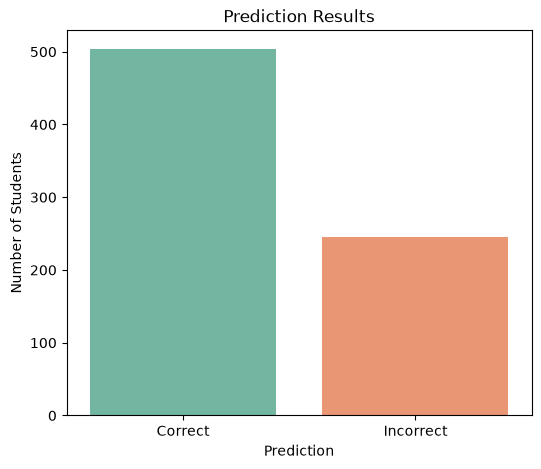

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=student_df,
    x="PredictionResult",
    palette="Set2"
)

plt.title("Prediction Results")

plt.xlabel("Prediction")

plt.ylabel("Number of Students")

plt.show()

## Key Findings

- The deployed **Random Forest** model achieved an **overall prediction accuracy of 67.2%** on the complete student dataset, demonstrating reliable performance during inference.
- Out of **750 students**, the model correctly predicted the placement outcomes of **504 students**, while **246 predictions** differed from the actual placement status.
- The confusion matrix indicates that the model correctly identified **223 placed students (True Positives)** and **281 non-placed students (True Negatives)**.
- The model generated **115 False Positives**, where students were predicted to be placed but were actually not placed, and **131 False Negatives**, where students who were ultimately placed were predicted as not placed.
- In addition to binary placement predictions, the model generated **placement probability scores**, providing a confidence measure for each prediction. These probabilities are used by the Placement Intelligence Platform to estimate placement readiness and support personalized career recommendations.
- The prediction validation demonstrates that the **Random Forest model** effectively captures the complex relationships between academic performance, technical skills, and placement outcomes. Although machine learning predictions are inherently probabilistic, the model provides sufficiently reliable results to support placement prediction, role recommendation, and personalized career guidance.

## Section 3 - Recommendation Engine Core

The recommendation engine extends the machine learning prediction by generating personalized career recommendations based on a student's academic profile, technical skills, placement probability, and career preferences.

Instead of relying solely on the model's prediction, the recommendation engine combines machine learning outputs with rule-based decision logic to provide actionable career guidance.

The recommendation engine consists of the following modules:

- Placement Readiness Assessment
- Company Recommendation
- Job Role Recommendation
- Skill Gap Analysis
- Career Guidance Report

These modules work together to generate a comprehensive Placement Intelligence Report for both existing and new students.

## Section 3.1 - Placement Readiness Assessment

In [59]:
def placement_readiness(probability):

    if probability >= 85:
        return "Excellent"
    elif probability >= 75:
        return "High"
    elif probability >= 60:
        return "Moderate"
    elif probability >= 40:
        return "Developing"
    else:
        return "Needs Improvement"

## Apply

In [60]:
student_df["PlacementReadiness"] = (
    student_df["PlacementProbability"]
    .apply(placement_readiness)
)

## Verify

In [61]:
student_df[
    [
        "Name",
        "PlacementProbability",
        "PlacementReadiness"
    ]
].head()

,Name,PlacementProbability,PlacementReadiness
0,Aditya Das,45.59,Developing
1,Vikram Pillai,76.46,High
2,Amit Gupta,76.76,High
3,Sayan Yadav,55.91,Developing
4,Sayan Mishra,52.67,Developing


## Visualization

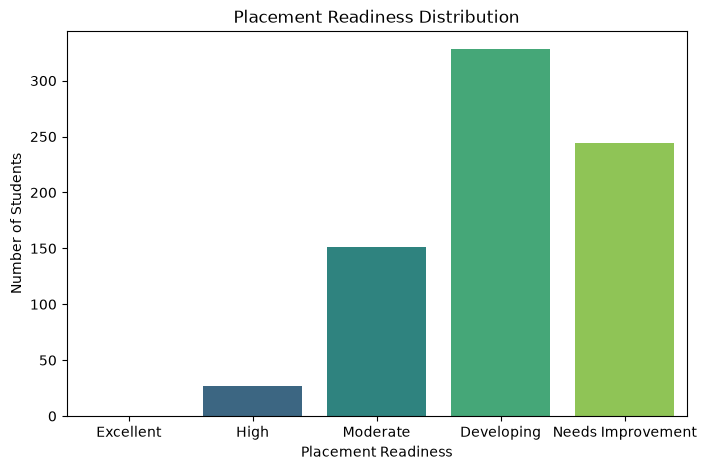

In [62]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=student_df,
    x="PlacementReadiness",
    order=[
        "Excellent",
        "High",
        "Moderate",
        "Developing",
        "Needs Improvement"
    ],
    palette="viridis"
)

plt.title("Placement Readiness Distribution")

plt.xlabel("Placement Readiness")

plt.ylabel("Number of Students")

plt.show()

## Summary Table

In [26]:
readiness_summary = (
    student_df["PlacementReadiness"]
    .value_counts()
    .reset_index()
)

readiness_summary.columns = [
    "Placement Readiness",
    "Student Count"
]

readiness_summary

,Placement Readiness,Student Count
0,Needs Improvement,572
1,Developing,105
2,Moderate,67
3,High,6


## Key Findings

- Students were classified into four placement readiness levels based on their predicted placement probabilities: **High, Moderate, Developing, and Needs Improvement**. No students achieved the **Excellent** readiness level in the current dataset.
- The majority of students (**572 out of 750, approximately 76.3%**) fall under the **Needs Improvement** category, indicating that most students require significant improvements in their academic profile, technical skills, projects, or practical experience before becoming placement-ready.
- **105 students (14.0%)** were classified as **Developing**, suggesting that these students have a reasonable foundation but would benefit from targeted improvements in coding skills, projects, internships, and communication.
- **67 students (8.9%)** achieved a **Moderate** placement readiness level, indicating that they are approaching placement readiness and can substantially improve their prospects with focused preparation.
- Only **6 students (0.8%)** were classified as **High** readiness, demonstrating that a very small proportion of students possess a highly competitive profile suitable for top placement opportunities.
- The placement readiness assessment converts raw prediction probabilities into meaningful readiness categories, making the model's output easier to interpret and more actionable for both students and placement coordinators.
- These readiness levels form the foundation of the recommendation engine by supporting personalized job role recommendations, company recommendations, skill-gap analysis, and career guidance tailored to each student's profile.

## Section 3.2 - Company Recommendation System

## Load Recommendation Data

In [27]:
companies_df = pd.read_sql(
    "SELECT * FROM companies",
    conn
)

company_roles_df = pd.read_sql(
    "SELECT * FROM companyroles",
    conn
)

company_eligibility_df = pd.read_sql(
    "SELECT * FROM companyeligibility",
    conn
)

roles_df = pd.read_sql(
    "SELECT * FROM roles",
    conn
)

branches_df = pd.read_sql(
    "SELECT * FROM branches",
    conn
)

skills_df = pd.read_sql(
    "SELECT * FROM skills",
    conn
)

student_skills_df = pd.read_sql(
    "SELECT * FROM studentskills",
    conn
)

role_skills_df = pd.read_sql(
    "SELECT * FROM roleskills",
    conn
)

## Merge Information

In [28]:
company_master = (
    company_roles_df
    .merge(companies_df, on="CompanyID")
    .merge(company_eligibility_df, on="CompanyRoleID")
    .merge(roles_df, on="RoleID")
    .merge(branches_df, on="BranchID")
)

## 3.2.1 Company Dataset Analysis

### Total Companies

In [29]:
print("Total Companies :", company_master["CompanyName"].nunique())

Total Companies : 49


### Total Roles

In [30]:
print("Total Roles :", company_master["RoleName"].nunique())

Total Roles : 35


### Branch Coverage

In [31]:
company_master["BranchName"].value_counts()

BranchName
Computer Science and Engineering             121
Electronics and Communication Engineering    111
Electrical Engineering                        59
Mechanical Engineering                        43
Civil Engineering                             13
Metallurgical and Materials Engineering       12
Chemical Engineering                          12
Biotechnology                                  2
Name: count, dtype: int64

### Company Categories

In [32]:
company_master["Category"].value_counts()

Category
Category-2    257
Category-3    116
Name: count, dtype: int64

### Package Distribution

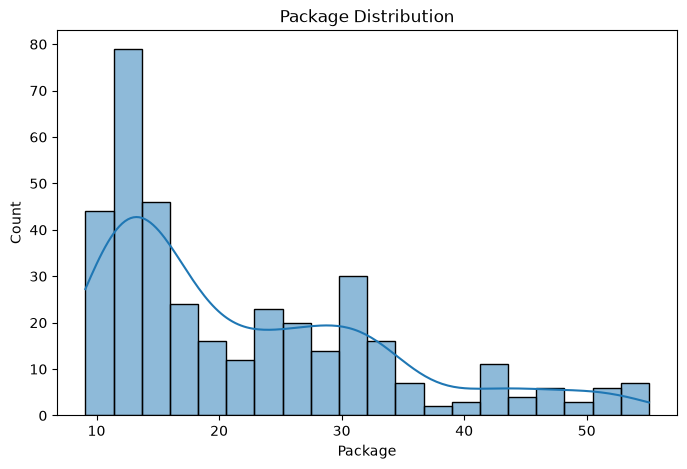

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(
    company_master["Package"],
    bins=20,
    kde=True
)

plt.title("Package Distribution")

plt.show()

### Minimum CGPA Distribution

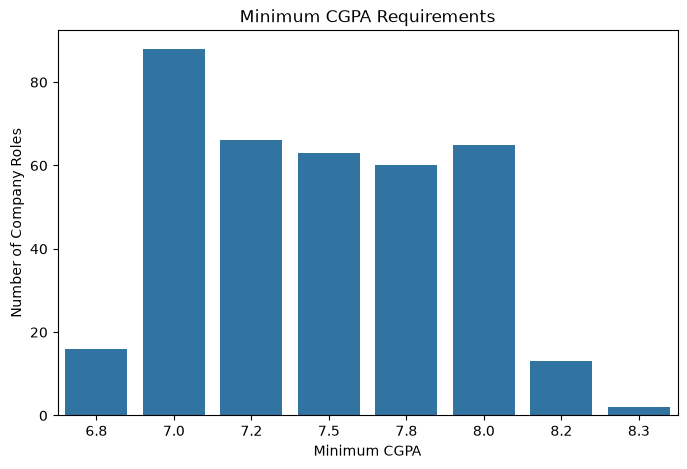

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=company_master,
    x="MinimumCGPA"
)

plt.title("Minimum CGPA Requirements")

plt.xlabel("Minimum CGPA")

plt.ylabel("Number of Company Roles")

plt.show()

### Highest Paying Companies

In [35]:
company_master[
    [
        "CompanyName",
        "RoleName",
        "Package"
    ]
].sort_values(
    "Package",
    ascending=False
).head(10)

,CompanyName,RoleName,Package
51,NVIDIA,VLSI Engineer,55.08
2,Microsoft,Backend Developer,53.11
22,Apple,Software Engineer,53.02
21,Apple,Software Engineer,53.02
45,NVIDIA,AI Engineer,52.87
0,Microsoft,Software Engineer,52.86
1,Microsoft,Software Engineer,52.86
3,Microsoft,Frontend Developer,52.65
4,Microsoft,Full Stack Developer,51.05
98,JP Morgan Chase,Risk Analyst,50.81


### Company Count by Industry

In [36]:
company_master["Industry"].value_counts()

Industry
Banking                  57
Consulting               56
Semiconductor            37
IT Services              26
Automobile               25
Software                 21
Analytics                21
Steel                    17
FinTech                  13
Oil & Gas                10
Consumer Electronics      8
Enterprise Software       8
Networking                8
Research & Consulting     8
Engineering               8
Energy                    8
Electronics               7
Engineering Software      7
Steel Equipment           7
Infrastructure            6
Manufacturing             6
Mining                    5
Petrochemicals            4
Name: count, dtype: int64

## 3.2.2 Company Recommendation Engine

## 1. Eligibility Function

In [37]:
def get_eligible_companies(student):

    eligible = company_master[
        (company_master["BranchName"] == student["BranchName"]) &
        (company_master["MinimumCGPA"] <= student["CGPA"])
    ].copy()

    return eligible

## 2. Recommendation Score

In [38]:
def calculate_recommendation_score(student, eligible):

    eligible = eligible.copy()

    
    probability = student["PlacementProbability"] / 100

    
    eligible["RoleBonus"] = np.where(
        eligible["RoleName"] == student["RoleName"],
        0.10,
        0.00
    )

    
    eligible["RecommendationScore"] = (
        probability +
        eligible["RoleBonus"]
    )

    return eligible

## 3. Recommendation Function

In [39]:
def recommend_companies(student, top_n=5):

    eligible = get_eligible_companies(student)

    if eligible.empty:
        return eligible

    recommended = calculate_recommendation_score(
        student,
        eligible
    )

    recommended["RecommendationReason"] = (
        recommended.apply(
            lambda row: generate_reason(row, student),
            axis=1
        )
    )

    return (
        recommended
        .sort_values(
            ["RecommendationScore", "Package"],
            ascending=[False, False]
        )
        .head(top_n)
    )

## 4. Recommendation Reason

In [40]:
def generate_reason(row, student):

    reasons = []

    if row["RoleName"] == student["RoleName"]:
        reasons.append("Matches your preferred role")

    reasons.append("You satisfy the branch and CGPA eligibility criteria")

    if student["PlacementProbability"] >= 80:
        reasons.append("High placement probability")

    elif student["PlacementProbability"] >= 60:
        reasons.append("Good placement probability")

    else:
        reasons.append("Suitable based on your current profile")

    return " | ".join(reasons)

## 5. Verify

In [41]:
for i in range(5):

    student = student_df.iloc[i]
    print("=" * 70)
    print("Student :", student["Name"])
    print("Placement Probability :", round(student["PlacementProbability"], 2), "%")
    print("Placement Readiness :", student["PlacementReadiness"])

    display(
        recommend_companies(student)[
            [
                "CompanyName",
                "RoleName",
                "Category",
                "Package",
                "RecommendationScore",
                "RecommendationReason"
            ]
        ]
    )

Student : Aditya Das
Placement Probability : 45.59 %
Placement Readiness : Needs Improvement


,CompanyName,RoleName,Category,Package,RecommendationScore,RecommendationReason
242,GreyB,Research Associate,Category-2,13.42,0.5559,Matches your preferred role | You satisfy the ...
245,GreyB,Research Engineer,Category-2,12.20,0.4559,You satisfy the branch and CGPA eligibility cr...


Student : Vikram Pillai
Placement Probability : 76.46 %
Placement Readiness : Moderate


,CompanyName,RoleName,Category,Package,RecommendationScore,RecommendationReason
245,GreyB,Research Engineer,Category-2,12.20,0.8646,Matches your preferred role | You satisfy the ...
242,GreyB,Research Associate,Category-2,13.42,0.7646,You satisfy the branch and CGPA eligibility cr...


Student : Amit Gupta
Placement Probability : 76.76 %
Placement Readiness : Moderate


,CompanyName,RoleName,Category,Package,RecommendationScore,RecommendationReason
245,GreyB,Research Engineer,Category-2,12.20,0.8676,Matches your preferred role | You satisfy the ...
242,GreyB,Research Associate,Category-2,13.42,0.7676,You satisfy the branch and CGPA eligibility cr...


Student : Sayan Yadav
Placement Probability : 55.91 %
Placement Readiness : Needs Improvement


,CompanyName,RoleName,Category,Package,RecommendationScore,RecommendationReason
242,GreyB,Research Associate,Category-2,13.42,0.6591,Matches your preferred role | You satisfy the ...
245,GreyB,Research Engineer,Category-2,12.20,0.5591,You satisfy the branch and CGPA eligibility cr...


Student : Sayan Mishra
Placement Probability : 52.67 %
Placement Readiness : Needs Improvement


,CompanyName,RoleName,Category,Package,RecommendationScore,RecommendationReason
242,GreyB,Research Associate,Category-2,13.42,0.6267,Matches your preferred role | You satisfy the ...
245,GreyB,Research Engineer,Category-2,12.20,0.5267,You satisfy the branch and CGPA eligibility cr...


## Key Findings

- A company recommendation engine was successfully developed by integrating machine learning predictions with company eligibility criteria stored in the relational database.
- Company recommendations are generated using a two-stage approach: eligibility filtering based on branch and minimum CGPA, followed by ranking using placement probability and preferred role alignment.
- Placement probability serves as the primary ranking factor, ensuring that recommendations are personalized according to each student's predicted placement readiness.
- Students receive recommendations only from companies for which they satisfy the minimum eligibility requirements, making the recommendations realistic and actionable.
- A preferred role bonus is incorporated into the recommendation score, allowing companies offering the student's desired role to be prioritized.
- The recommendation engine also provides an explanation for each recommendation, improving transparency by highlighting factors such as role alignment, eligibility satisfaction, and placement readiness.
- The developed recommendation system is modular and can be directly integrated into the FastAPI backend and Streamlit dashboard to provide personalized company recommendations for both existing students and new users.

## Section 3.3 - Role Recommendation System


## Dictionaries for Student Skills and Skills for Roles

In [42]:
student_skill_map = (
    student_skills_df
    .groupby("StudentID")["SkillID"]
    .apply(set)
    .to_dict()
)

role_skill_map = (
    role_skills_df
    .groupby("RoleID")["SkillID"]
    .apply(set)
    .to_dict()
)

## Names of Skills

In [43]:
skill_lookup = (
    skills_df
    .set_index("SkillID")["SkillName"]
    .to_dict()
)

## 1. Skill Match Function

In [44]:
def calculate_skill_match(student_id, role_id):

    student_skills = student_skill_map.get(student_id, set())
    role_skills = role_skill_map.get(role_id, set())

    if len(role_skills) == 0:

        return {
            "SkillMatch": 0,
            "MatchedSkills": 0,
            "RequiredSkills": 0
        }

    matching_skills = student_skills.intersection(role_skills)
    
    skill_match = (
        len(matching_skills) /
        len(role_skills)
    ) * 100

    return {
        "SkillMatch": round(skill_match, 2),
        "MatchedSkills": len(matching_skills),
        "RequiredSkills": len(role_skills)
    }

## 2. Role Recommendation Function

In [45]:
def recommend_roles(student, top_n=5):

    recommendations = []

    for role_id in role_skill_map.keys():

        match_info = calculate_skill_match(
        student["StudentID"],
        role_id
        )

        skill_match = match_info["SkillMatch"]

        role = roles_df[
            roles_df["RoleID"] == role_id
        ].iloc[0]

        score = skill_match

        if role["RoleName"] == student["RoleName"]:
            score += 10

        score += (
            student["PlacementProbability"] / 100
        ) * 10

        recommendations.append({

        "RoleName": role["RoleName"],
        "RoleType": role["RoleType"],
        "SkillMatch": skill_match,
        "MatchedSkills": match_info["MatchedSkills"],
        "RequiredSkills": match_info["RequiredSkills"],
        "RecommendationScore": round(score,2)

    })

    recommendations = pd.DataFrame(recommendations)

    return recommendations.sort_values(
        "RecommendationScore",
        ascending=False
    ).head(top_n)

## 3. Verify

In [46]:
for i in range(5):

    student = student_df.iloc[i]

    print("="*70)

    print("Student :", student["Name"])

    print("Placement Probability :", round(student["PlacementProbability"],2), "%")

    display(

        recommend_roles(student)

    )

Student : Aditya Das
Placement Probability : 45.59 %


,RoleName,RoleType,SkillMatch,MatchedSkills,RequiredSkills,RecommendationScore
27,Research Associate,Research,100.00,5,5,114.56
11,Data Analyst,Analytics,57.14,4,7,61.70
10,QA Engineer,Software,50.00,2,4,54.56
5,Data Scientist,Software,42.86,3,7,47.42
12,Business Analyst,Analytics,40.00,2,5,44.56


Student : Vikram Pillai
Placement Probability : 76.46 %


,RoleName,RoleType,SkillMatch,MatchedSkills,RequiredSkills,RecommendationScore
28,Research Engineer,Research,100.0,6,6,117.65
22,Metallurgical Engineer,Core,50.0,2,4,57.65
27,Research Associate,Research,40.0,2,5,47.65
25,Project Engineer,Core,40.0,2,5,47.65
10,QA Engineer,Software,25.0,1,4,32.65


Student : Amit Gupta
Placement Probability : 76.76 %


,RoleName,RoleType,SkillMatch,MatchedSkills,RequiredSkills,RecommendationScore
28,Research Engineer,Research,83.33,5,6,101.01
27,Research Associate,Research,40.00,2,5,47.68
10,QA Engineer,Software,25.00,1,4,32.68
22,Metallurgical Engineer,Core,25.00,1,4,32.68
17,Hardware Engineer,Electronics,20.00,1,5,27.68


Student : Sayan Yadav
Placement Probability : 55.91 %


,RoleName,RoleType,SkillMatch,MatchedSkills,RequiredSkills,RecommendationScore
27,Research Associate,Research,80.00,4,5,95.59
10,QA Engineer,Software,50.00,2,4,55.59
17,Hardware Engineer,Electronics,40.00,2,5,45.59
25,Project Engineer,Core,40.00,2,5,45.59
28,Research Engineer,Research,33.33,2,6,38.92


Student : Sayan Mishra
Placement Probability : 52.67 %


,RoleName,RoleType,SkillMatch,MatchedSkills,RequiredSkills,RecommendationScore
27,Research Associate,Research,100.00,5,5,115.27
10,QA Engineer,Software,50.00,2,4,55.27
28,Research Engineer,Research,50.00,3,6,55.27
11,Data Analyst,Analytics,42.86,3,7,48.13
25,Project Engineer,Core,40.00,2,5,45.27


## Section 3.4 - Skill Gap Analysis


## 1. Analysis Function

In [47]:
def analyze_skill_gap(student, role_name):

    student_id = student["StudentID"]

    student_skill_ids = student_skill_map.get(student_id, set())

    role_id = roles_df.loc[
        roles_df["RoleName"] == role_name,
        "RoleID"
    ].iloc[0]

    required_skill_ids = role_skill_map.get(role_id, set())

    matched_skill_ids = (
        student_skill_ids &
        required_skill_ids
    )

    missing_skill_ids = (
        required_skill_ids -
        student_skill_ids
    )

    matched_skill_names = [
        skill_lookup[skill]
        for skill in matched_skill_ids
    ]

    missing_skill_names = [
        skill_lookup[skill]
        for skill in missing_skill_ids
    ]

    required_skill_names = [
        skill_lookup[skill]
        for skill in required_skill_ids
    ]

    skill_match = (
        len(matched_skill_ids) /
        len(required_skill_ids)
    ) * 100

    return {

        "Role": role_name,
        "SkillMatch": round(skill_match,2),
        "MatchedSkills": matched_skill_names,
        "MissingSkills": missing_skill_names,
        "RequiredSkills": required_skill_names,
        "MatchedCount": len(matched_skill_ids),
        "RequiredCount": len(required_skill_ids)

    }

## 2. Verify


In [48]:
student = student_df.iloc[3]

recommended_role = recommend_roles(student).iloc[0]["RoleName"]

analysis = analyze_skill_gap(
    student,
    recommended_role
)

analysis

{'Role': 'Research Associate',
 'SkillMatch': 80.0,
 'MatchedSkills': ['Problem Solving',
  'Python',
  'Bioinformatics',
  'Communication'],
 'MissingSkills': ['Data Visualization'],
 'RequiredSkills': ['Python',
  'Bioinformatics',
  'Communication',
  'Problem Solving',
  'Data Visualization'],
 'MatchedCount': 4,
 'RequiredCount': 5}

## 3. Learning Recommendations


In [49]:
def learning_recommendations(missing_skills):

    recommendations = []

    for skill in missing_skills:

        recommendations.append(
            f"Learn {skill}"
        )

    return recommendations

In [50]:
recommendations = learning_recommendations(
    analysis["MissingSkills"]
)

print()

print("Learning Recommendations")

for rec in recommendations:

    print("•", rec)


Learning Recommendations
• Learn Data Visualization


## 4. Verify


In [51]:
for i in range(5):

    student = student_df.iloc[i]

    recommended_role = recommend_roles(student).iloc[0]["RoleName"]

    analysis = analyze_skill_gap(
        student,
        recommended_role
    )

    print("="*80)
    print("Student :", student["Name"])
    print("Recommended Role :", analysis["Role"])

    print(
        "Skill Match :",
        f'{analysis["SkillMatch"]}%'
    )

    print(
        "Skills Matched :",
        f'{analysis["MatchedCount"]}/{analysis["RequiredCount"]}'
    )

    print()

    print("Missing Skills")

    for skill in analysis["MissingSkills"]:

        print("-", skill)

    print()
    
    print("Learning Recommendations")

    for rec in learning_recommendations(
        analysis["MissingSkills"]
    ):

        print("•", rec)

Student : Aditya Das
Recommended Role : Research Associate
Skill Match : 100.0%
Skills Matched : 5/5

Missing Skills

Learning Recommendations
Student : Vikram Pillai
Recommended Role : Research Engineer
Skill Match : 100.0%
Skills Matched : 6/6

Missing Skills

Learning Recommendations
Student : Amit Gupta
Recommended Role : Research Engineer
Skill Match : 83.33%
Skills Matched : 5/6

Missing Skills
- PCR

Learning Recommendations
• Learn PCR
Student : Sayan Yadav
Recommended Role : Research Associate
Skill Match : 80.0%
Skills Matched : 4/5

Missing Skills
- Data Visualization

Learning Recommendations
• Learn Data Visualization
Student : Sayan Mishra
Recommended Role : Research Associate
Skill Match : 100.0%
Skills Matched : 5/5

Missing Skills

Learning Recommendations


## Key Findings

- A Skill Gap Analysis module was successfully developed by comparing each student's existing skills with the required skills of their recommended job roles.
- The system identifies matched skills, missing skills, and computes the overall skill match percentage for every recommended role.
- Personalized learning recommendations are automatically generated based on the identified missing skills, providing students with a clear roadmap for improving their technical competencies.
- Students with a 100% skill match are identified as fully prepared for their recommended role, while others receive targeted suggestions to bridge their skill gaps.
- The Skill Gap Analysis module complements the role recommendation system by transforming role recommendations into actionable career development plans, making the Placement Intelligence Platform more intelligent and student-centric.

## Section 3.5 - Career Guidance Module


## 1. Career Guidance Function

In [52]:
def generate_career_guidance(student):

    strengths = []
    improvements = []
    recommendations = []

    
    if student["PlacementReadiness"] in ["Excellent", "High"]:
        strengths.append("Strong placement readiness.")

    else:

        improvements.append(
            "Improve your overall placement readiness."
        )

    
    if student["AcademicScore"] >= 80:

        strengths.append(
            "Excellent academic performance."
        )

    else:

        improvements.append(
            "Focus on improving academic performance."
        )

    
    if student["TechnicalScore"] >= 80:

        strengths.append(
            "Strong technical skill set."
        )

    else:

        improvements.append(
            "Strengthen your technical skills."
        )

    
    if student["CommunicationScore"] >= 80:

        strengths.append(
            "Good communication skills."
        )

    else:

        improvements.append(
            "Improve communication and interview skills."
        )

    # Experience
    if student["ExperienceScore"] >= 80:

        strengths.append(
            "Good practical experience through projects and internships."
        )

    else:

        improvements.append(
            "Build more projects and internships."
        )

    
    recommended_role = recommend_roles(student).iloc[0]["RoleName"]

    recommendations.append(
        f"Focus on preparing for {recommended_role} roles."
    )

    
    analysis = analyze_skill_gap(
        student,
        recommended_role
    )

    for skill in analysis["MissingSkills"]:

        recommendations.append(
            f"Learn {skill}."
        )

    return {

        "Strengths": strengths,
        "AreasForImprovement": improvements,
        "CareerRecommendations": recommendations

    }

## 2. Verify

In [53]:
for i in range(5):

    student = student_df.iloc[i]

    guidance = generate_career_guidance(student)

    print("="*80)
    print("Student :", student["Name"])
    print()
    print("Strengths")

    for s in guidance["Strengths"]:
        print("✓", s)

    print()

    print("Areas for Improvement")

    for a in guidance["AreasForImprovement"]:
        print("-", a)

    print()

    print("Career Recommendations")

    for r in guidance["CareerRecommendations"]:
        print("•", r)

    print()


Student : Aditya Das

Strengths
✓ Excellent academic performance.

Areas for Improvement
- Improve your overall placement readiness.
- Strengthen your technical skills.
- Improve communication and interview skills.
- Build more projects and internships.

Career Recommendations
• Focus on preparing for Research Associate roles.

Student : Vikram Pillai

Strengths
✓ Excellent academic performance.
✓ Strong technical skill set.

Areas for Improvement
- Improve your overall placement readiness.
- Improve communication and interview skills.
- Build more projects and internships.

Career Recommendations
• Focus on preparing for Research Engineer roles.

Student : Amit Gupta

Strengths
✓ Excellent academic performance.
✓ Strong technical skill set.
✓ Good communication skills.

Areas for Improvement
- Improve your overall placement readiness.
- Build more projects and internships.

Career Recommendations
• Focus on preparing for Research Engineer roles.
• Learn PCR.

Student : Sayan Yadav

St

## Key Findings

- A Career Guidance module was successfully developed by integrating placement prediction, role recommendation, and skill gap analysis into a unified guidance system.
- The module automatically identifies each student's strengths and areas for improvement based on academic performance, technical skills, communication ability, practical experience, and placement readiness.
- Personalized career recommendations are generated by combining the student's recommended role with the identified missing skills, providing a clear roadmap for future preparation.
- The Career Guidance module enhances the Placement Intelligence Platform by transforming predictive insights into actionable career advice, enabling students to make informed decisions about their skill development and placement preparation.

## Section 4 - New Student Inference Pipeline


The New Student Inference Pipeline enables the Placement Intelligence Platform to generate placement predictions and personalized career recommendations for students who are not present in the database.
Unlike previous sections that perform inference on existing student records, this module accepts student information as input, performs feature engineering, predicts placement outcomes, generates recommendations, identifies skill gaps, and provides career guidance through a single unified pipeline.




## 1. Function Skeleton and Feature Engineering

In [54]:
def get_placement_readiness(probability):

    if probability >= 90:
        return "Excellent"

    elif probability >= 80:
        return "High"

    elif probability >= 70:
        return "Moderate"

    elif probability >= 60:
        return "Developing"

    else:
        return "Needs Improvement"

def predict_new_student(

    branch_name,
    preferred_role,
    cgpa,
    coding_score,
    dsa_solved,
    projects,
    internships,
    communication_score,
    aptitude_score

):

    # ----------------------------------
    # Feature Engineering
    # ----------------------------------

    academic_score = (
        cgpa * 10 +
        aptitude_score
    ) / 2

    technical_score = (
        coding_score +
        dsa_solved / 10
    ) / 2

    experience_score = (
        projects * 15 +
        internships * 20
    )

    overall_score = (
        academic_score +
        technical_score +
        communication_score +
        experience_score
    ) / 4

    # ----------------------------------
    # Create Input DataFrame
    # ----------------------------------

    input_df = pd.DataFrame([{

        "CGPA": cgpa,
        "CodingScore": coding_score,
        "DSASolved": dsa_solved,
        "Projects": projects,
        "Internships": internships,
        "CommunicationScore": communication_score,
        "AptitudeScore": aptitude_score,
        "AcademicScore": academic_score,
        "TechnicalScore": technical_score,
        "ExperienceScore": experience_score,
        "OverallScore": overall_score,
        "SkillCount": 0

    }])

    input_df = input_df[feature_columns]

    # ----------------------------------
    # Scale Features
    # ----------------------------------

    scaled_input = scaler.transform(input_df)

    # ----------------------------------
    # Placement Prediction
    # ----------------------------------

    prediction = placement_model.predict(
        scaled_input
    )[0]

    prediction_label = label_encoder.inverse_transform(
        [prediction]
    )[0]

    # ----------------------------------
    # Placement Probability
    # ----------------------------------

    probability = (
        placement_model
        .predict_proba(scaled_input)[0][1]
    ) * 100

    probability = float(round(probability, 2))

    # ----------------------------------
    # Placement Readiness
    # ----------------------------------

    readiness = get_placement_readiness(
        probability
    )

    # ----------------------------------
    # Return Results
    # ----------------------------------

    return {

        "Branch": branch_name,
        "PreferredRole": preferred_role,
        "PlacementPrediction": prediction_label,
        "PlacementProbability": probability,
        "PlacementReadiness": readiness

    }

## 2. Verify

In [55]:
result = predict_new_student(

    branch_name="Computer Science and Engineering",
    preferred_role="AI Engineer",
    cgpa=8.7,
    coding_score=90,
    dsa_solved=500,
    projects=4,
    internships=2,
    communication_score=82,
    aptitude_score=88

)

result

{'Branch': 'Computer Science and Engineering',
 'PreferredRole': 'AI Engineer',
 'PlacementPrediction': 'Placed',
 'PlacementProbability': 99.64,
 'PlacementReadiness': 'Excellent'}

## Verify Different Student Profiles

In [56]:
result = predict_new_student(

    branch_name="Computer Science and Engineering",
    preferred_role="Backend Developer",
    cgpa=7.4,
    coding_score=68,
    dsa_solved=180,
    projects=2,
    internships=1,
    communication_score=72,
    aptitude_score=70

)

result

{'Branch': 'Computer Science and Engineering',
 'PreferredRole': 'Backend Developer',
 'PlacementPrediction': 'Placed',
 'PlacementProbability': 81.01,
 'PlacementReadiness': 'High'}

In [57]:
result = predict_new_student(

    branch_name="Mechanical Engineering",
    preferred_role="Design Engineer",
    cgpa=6.2,
    coding_score=42,
    dsa_solved=25,
    projects=1,
    internships=0,
    communication_score=55,
    aptitude_score=48

)

result

{'Branch': 'Mechanical Engineering',
 'PreferredRole': 'Design Engineer',
 'PlacementPrediction': 'Not Placed',
 'PlacementProbability': 14.35,
 'PlacementReadiness': 'Needs Improvement'}

In [58]:
result = predict_new_student(

    branch_name="Computer Science and Engineering",
    preferred_role="Software Engineer",
    cgpa=6.8,
    coding_score=55,
    dsa_solved=60,
    projects=1,
    internships=0,
    communication_score=60,
    aptitude_score=58

)

result

{'Branch': 'Computer Science and Engineering',
 'PreferredRole': 'Software Engineer',
 'PlacementPrediction': 'Not Placed',
 'PlacementProbability': 22.87,
 'PlacementReadiness': 'Needs Improvement'}

## Key Findings

- A reusable New Student Inference Pipeline was successfully developed to generate placement predictions for students who are not present in the database.
- The pipeline recreates the complete feature engineering process used during model training, ensuring consistency between the training and inference stages.
- User-provided academic and technical information is transformed, scaled using the trained StandardScaler, and passed through the Logistic Regression model to predict placement outcomes, placement probability, and placement readiness.
- The modular implementation enables the inference pipeline to be reused across different deployment environments, making it suitable for integration into the FastAPI backend and Streamlit frontend.
- While the current pipeline focuses on placement prediction and readiness assessment, advanced recommendation modules such as Company Recommendation, Role Recommendation, Skill Gap Analysis, and Career Guidance require the student's technical skill profile. These modules will be integrated into the deployed application by collecting the required skill information through the user interface.

# Notebook Summary

In this notebook, the trained Placement Prediction model was successfully deployed into an inference pipeline capable of generating real-time placement predictions and personalized career insights.

The notebook began by loading the trained Logistic Regression model, preprocessing objects, and student data from the MySQL database. The complete feature engineering pipeline developed during training was recreated to ensure consistency between model training and inference.

Placement predictions and placement probabilities were generated for existing students, followed by model validation and placement readiness assessment. Based on the predicted probabilities, students were categorized into multiple readiness levels to provide a more interpretable evaluation of their placement preparedness.

Building upon the prediction results, a Company Recommendation System was developed to identify eligible companies based on branch and CGPA while incorporating placement probability and role preferences into the recommendation process. A Role Recommendation System was then implemented using student skills and role-specific skill requirements to recommend the most suitable career roles for each student.

To provide actionable insights, a Skill Gap Analysis module was introduced to compare the student's existing skills with the required skills for recommended roles, identifying missing competencies and generating personalized learning recommendations. Finally, a Career Guidance module integrated the outputs of all previous components to generate personalized strengths, areas for improvement, and career recommendations for each student.

The notebook concluded with the development of a reusable New Student Inference Pipeline capable of predicting placement outcomes for users who are not present in the database. This pipeline recreates the complete preprocessing workflow and serves as the foundation for real-time predictions in the deployed application.

Overall, this notebook transformed the trained machine learning model into a complete inference and recommendation system, bridging the gap between predictive analytics and intelligent career guidance. The modular implementation ensures that the developed pipeline can be seamlessly integrated into the FastAPI backend and Streamlit frontend during the deployment phase of the Placement Intelligence Platform.